In [ ]:
# 🏥 Health Insurance Cost Prediction

## Objective
To predict health insurance costs using Machine Learning
based on customer attributes like age, BMI, and smoking status.

## Dataset
- Records: 1,300+
- Features: Age, Gender, BMI, Children, Smoking Status, Location
- Target: Health Insurance Price

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 4021579-Health_insurance_cost.xlsx to 4021579-Health_insurance_cost.xlsx


In [ ]:
df = pd.read_excel("4021579-Health_insurance_cost.xlsx")

In [ ]:
df.head()

,age,gender,BMI,Children,smoking_status,location,health_insurance_price
0,19.0,female,NaN,0,yes,southwest,16884.92400
1,18.0,male,33.770,1,no,southeast,1725.55230
2,28.0,male,33.000,3,no,southeast,4449.46200
3,33.0,male,22.705,0,no,northwest,21984.47061
4,32.0,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.shape

(1338, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     1310 non-null   float64
 1   gender                  1338 non-null   object 
 2   BMI                     1315 non-null   float64
 3   Children                1338 non-null   int64  
 4   smoking_status          1338 non-null   object 
 5   location                1338 non-null   object 
 6   health_insurance_price  1336 non-null   float64
dtypes: float64(3), int64(1), object(3)
memory usage: 73.3+ KB


In [ ]:
df.isnull().sum()

,0
age,28
gender,0
BMI,23
Children,0
smoking_status,0
location,0
health_insurance_price,2


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,age,BMI,Children,health_insurance_price
count,1309.000000,1314.000000,1337.000000,1335.000000
mean,39.181818,30.638253,1.095737,13277.238554
std,14.049681,6.112628,1.205571,12113.150034
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.205000,0.000000,4746.698450
50%,39.000000,30.305000,1.000000,9386.161300
75%,51.000000,34.580000,2.000000,16622.107580
max,64.000000,53.130000,5.000000,63770.428010


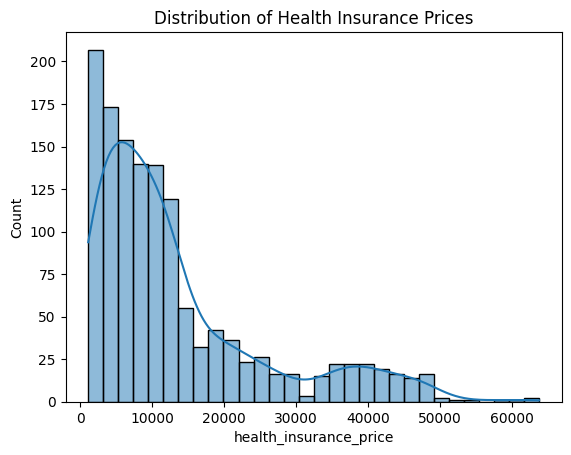

In [ ]:
sns.histplot(df['health_insurance_price'],kde = True)
plt.title("Distribution of Health Insurance Prices")
plt.show()

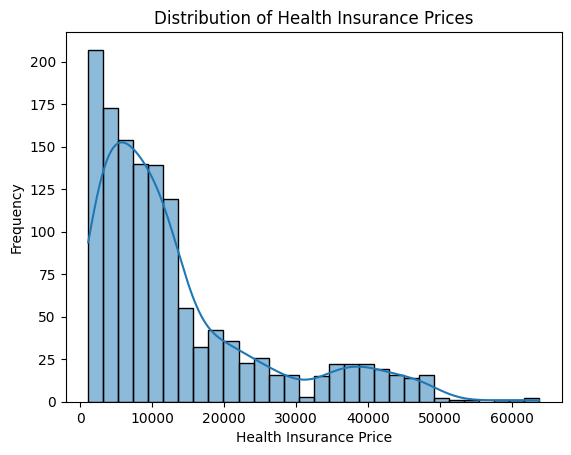

In [ ]:
sns.histplot(df['health_insurance_price'],kde = True)
plt.title("Distribution of Health Insurance Prices")
plt.xlabel("Health Insurance Price")
plt.ylabel("Frequency")
plt.show()

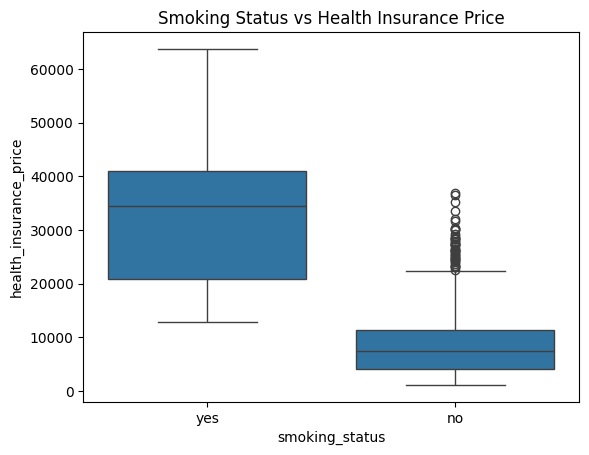

In [ ]:
sns.boxplot(x = "smoking_status", y = "health_insurance_price", data = df)
plt.title("Smoking Status vs Health Insurance Price")
plt.show()

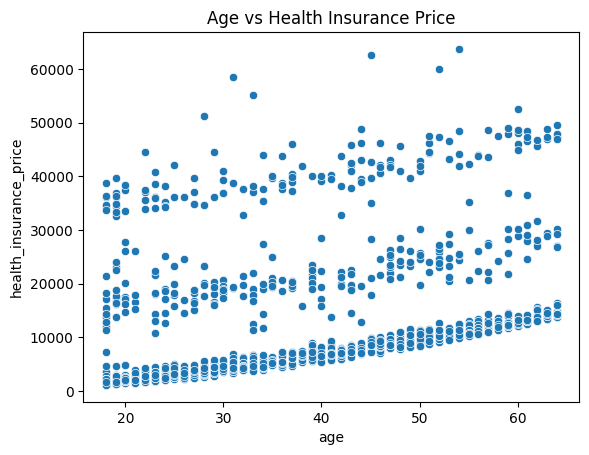

In [ ]:
sns.scatterplot(x = "age", y = "health_insurance_price", data = df)
plt.title("Age vs Health Insurance Price")
plt.show()

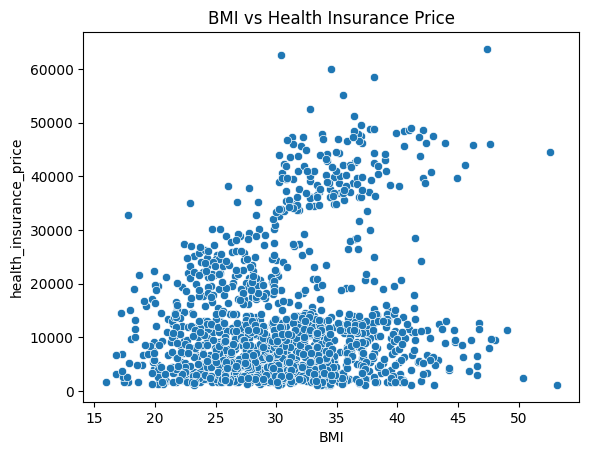

In [ ]:
sns.scatterplot(x = "BMI", y = "health_insurance_price", data = df)
plt.title("BMI vs Health Insurance Price")
plt.show()

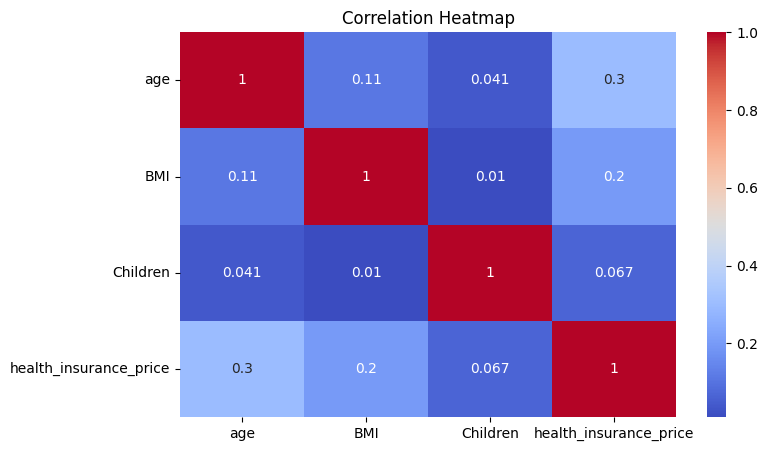

In [ ]:
numeric_df = df.select_dtypes(include = ["number"])
plt.figure(figsize = (8,5))
sns.heatmap(numeric_df.corr(), annot = True, cmap = "coolwarm")
plt.title("Correlation Heatmap")
plt.show()

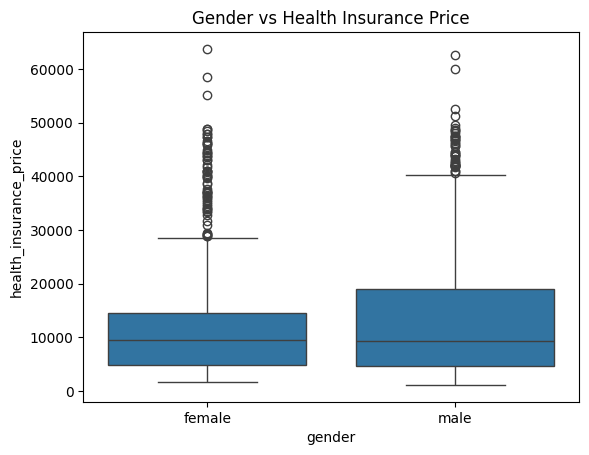

In [ ]:
sns.boxplot(x = "gender" , y = "health_insurance_price", data = df)
plt.title("Gender vs Health Insurance Price")
plt.show()

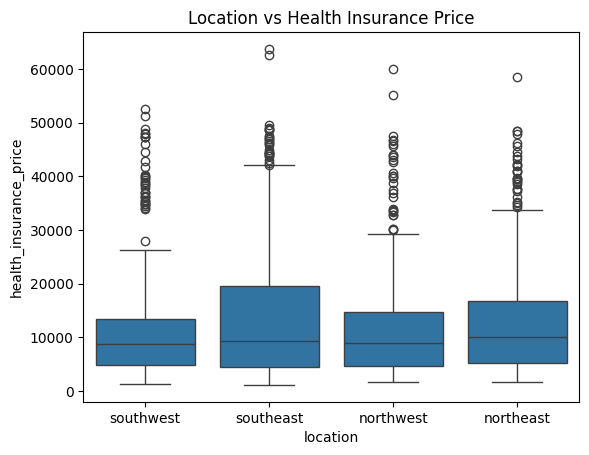

In [ ]:
sns.boxplot(x = "location", y = "health_insurance_price", data = df)
plt.title("Location vs Health Insurance Price")
plt.show()

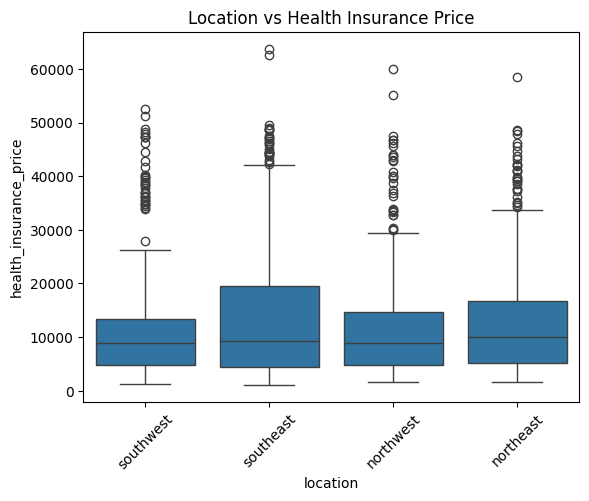

In [ ]:
sns.boxplot(x = "location", y = "health_insurance_price", data = df)
plt.title("Location vs Health Insurance Price")
plt.xticks(rotation = 45)
plt.show()

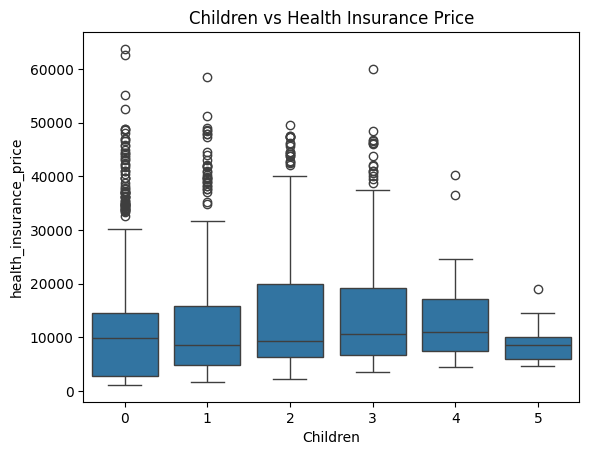

In [ ]:
sns.boxplot(x = "Children", y = "health_insurance_price", data = df)
plt.title("Children vs Health Insurance Price")
plt.show()

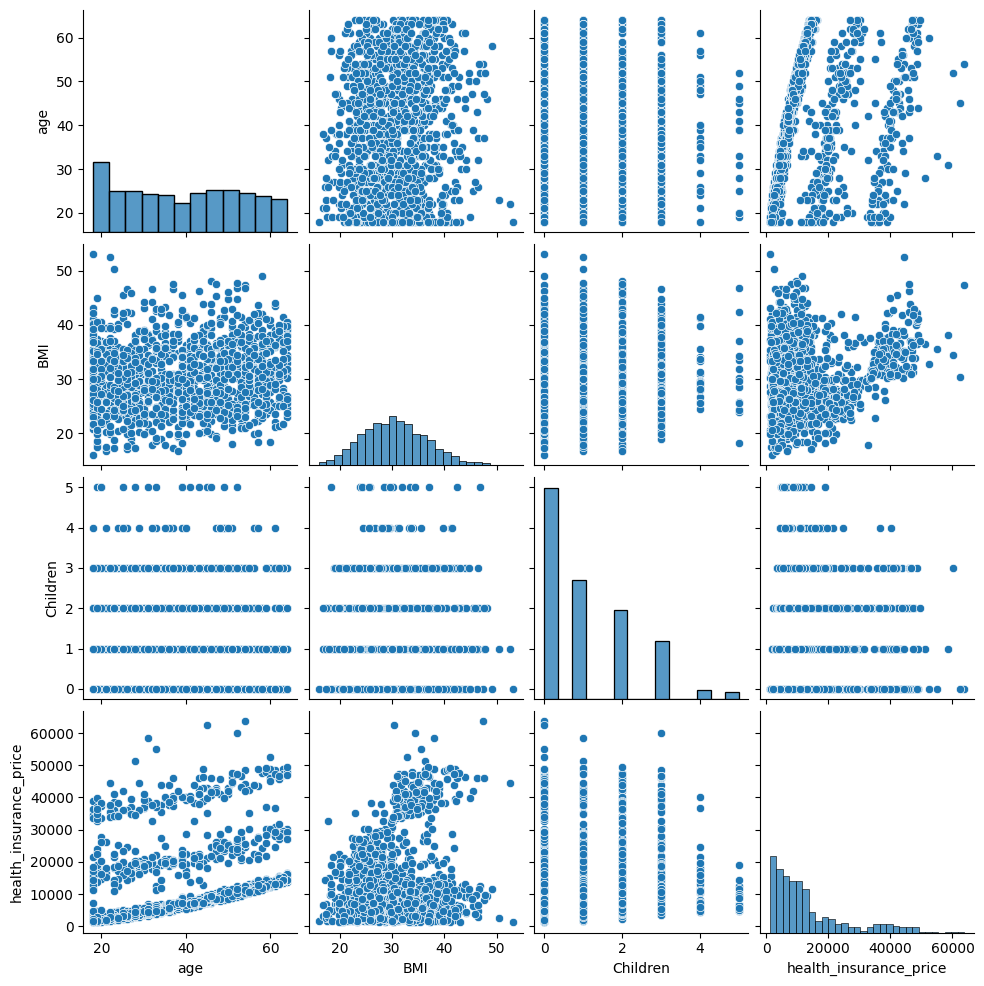

In [ ]:
sns.pairplot(df)
plt.show()

In [ ]:
df["age"] = df["age"].fillna(df["age"].mean())
df["BMI"] = df["BMI"].fillna(df["BMI"].mean())
df["health_insurance_price"] = df["health_insurance_price"].fillna(df["health_insurance_price"].mean())

In [ ]:
df.isnull().sum()

,0
age,0
gender,0
BMI,0
Children,0
smoking_status,0
location,0
health_insurance_price,0


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["gender"] = le.fit_transform(df["gender"])
df["smoking_status"] = le.fit_transform(df["smoking_status"])
df["location"] = le.fit_transform(df["location"])

In [ ]:
df.head()

,age,gender,BMI,Children,smoking_status,location,health_insurance_price
0,19.0,0,30.638253,0,1,3,16884.92400
1,18.0,1,33.770000,1,0,2,1725.55230
2,28.0,1,33.000000,3,0,2,4449.46200
3,33.0,1,22.705000,0,0,1,21984.47061
4,32.0,1,28.880000,0,0,1,3866.85520


In [ ]:
X = df.drop("health_insurance_price",axis = 1)
y = df["health_insurance_price"]

In [ ]:
X.head()

,age,gender,BMI,Children,smoking_status,location
0,19.0,0,30.638253,0,1,3
1,18.0,1,33.770000,1,0,2
2,28.0,1,33.000000,3,0,2
3,33.0,1,22.705000,0,0,1
4,32.0,1,28.880000,0,0,1


In [ ]:
y.head()

,health_insurance_price
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

In [ ]:
X_train.shape

(1069, 6)

In [ ]:
X_test.shape

(268, 6)

In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred = lr.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)
print("MAE:-",mae)
print("MSE:-",mse)
print("RMSE:-",rmse)
print("R2:-",r2)

MAE:- 4259.770637362856
MSE:- 36685137.64106536
RMSE:- 6056.825706677167
R2:- 0.8003595808796804


In [ ]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
dt.fit(X_train,y_train)

DecisionTreeRegressor()

In [ ]:
dt_pred = dt.predict(X_test)

In [ ]:
mae_dt = mean_absolute_error(y_test,dt_pred)
mse_dt = mean_squared_error(y_test,dt_pred)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test,dt_pred)
print("MAE:-",mae_dt)
print("MSE:-",mse_dt)
print("RMSE:-",rmse_dt)
print("R2:-",r2_dt)

MAE:- 3273.5128491216838
MSE:- 44760856.96366727
RMSE:- 6690.355518480858
R2:- 0.7564115383225887


In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()
rf.fit(X_train,y_train)

RandomForestRegressor()

In [ ]:
rf_pred = rf.predict(X_test)

In [ ]:
mae_rf = mean_absolute_error(y_test,rf_pred)
mse_rf = mean_squared_error(y_test,rf_pred)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test,rf_pred)
print("MAE:-",mae_rf)
print("MSE:-",mse_rf)
print("RMSE:-",rmse_rf)
print("R2:-",r2_rf)

MAE:- 2707.929060273446
MSE:- 22005486.522733107
RMSE:- 4691.0005886519675
R2:- 0.8802462022814589


In [ ]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor()
knn.fit(X_train,y_train)

KNeighborsRegressor()

In [ ]:
knn_pred = knn.predict(X_test)

In [ ]:
mae_knn = mean_absolute_error(y_test,knn_pred)
mse_knn = mean_squared_error(y_test,knn_pred)
rmse_knn = np.sqrt(mse_knn)
r2_knn = r2_score(y_test,knn_pred)
print("MAE:-",mae_knn)
print("MSE:-",mse_knn)
print("RMSE:-",rmse_knn)
print("R2:-",r2_knn)

MAE:- 8906.645789086733
MSE:- 172398672.21724662
RMSE:- 13130.06748715507
R2:- 0.06180689537033479


In [ ]:
model_results = {
    'Model' : ["Linear Regression","Decision Tree","Random Forest","KNN"],
    'MAE' : [mae,mae_dt,mae_rf,mae_knn],
    'MSE' : [mse,mse_dt,mse_rf,mse_knn],
    'RMSE' : [rmse,rmse_dt,rmse_rf,rmse_knn],
    'R2' : [r2,r2_dt,r2_rf,r2_knn]
}
results_df = pd.DataFrame(model_results)
results_df

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,4259.770637,3.668514e+07,6056.825707,0.800360
1,Decision Tree,3273.512849,4.476086e+07,6690.355518,0.756412
2,Random Forest,2707.929060,2.200549e+07,4691.000589,0.880246
3,KNN,8906.645789,1.723987e+08,13130.067487,0.061807


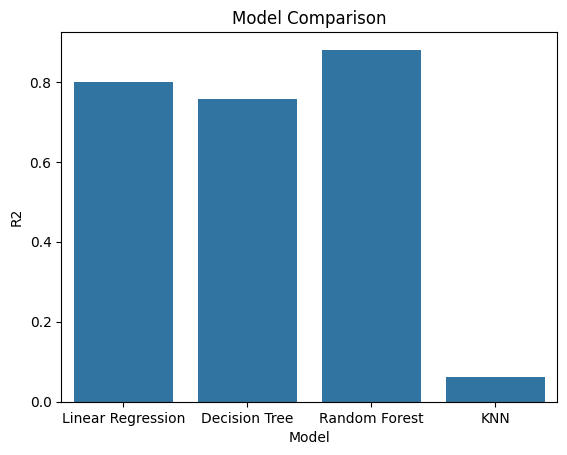

In [ ]:
sns.barplot(x = "Model", y = "R2", data = results_df)
plt.title("Model Comparison")
plt.show()

In [ ]:
## 🏆 Conclusion

After benchmarking 4 regression models:
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- KNN Regressor

**Random Forest Regressor** was selected as best model
based on highest R² score and lowest RMSE value.

### Key Cost Drivers Identified:
- Smoking status is strongest predictor of insurance cost
- Higher BMI directly correlates with increased charges
- Age shows positive correlation with insurance price